# Pre-processing
## Objectifs 
### 1. Mettre les donnees dans un format propice au ML
    - Train / Test
    - Encodage
    - Nettoyage des Nan
### 2. Ameliorere la preformance de model 
    - Feature Selection
    - Feature Engineering
    - Feature Scaling
    - Suppression des Outliers

In [2]:
import numpy as np # type: ignore
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
data = pd.read_excel('dataset.xlsx')
data.head()

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Pre-processing

In [4]:
df = data.copy()

In [5]:
df.head()

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Creation des sous-ensembles (suite au EDA)

In [31]:
missing_rate = (df.isna().sum() / df.shape[0]).sort_values(ascending=True)# Taux de valeur manquante 
print(missing_rate)

Patient age quantile                                0.000000
est_malade                                          0.000000
SARS-Cov-2 exam result                              0.000000
Influenza A                                         0.760099
Influenza B                                         0.760099
Respiratory Syncytial Virus                         0.760099
Parainfluenza 1                                     0.760454
Metapneumovirus                                     0.760454
Bordetella pertussis                                0.760454
Inf A H1N1 2009                                     0.760454
CoronavirusOC43                                     0.760454
Coronavirus229E                                     0.760454
Parainfluenza 4                                     0.760454
Adenovirus                                          0.760454
Chlamydophila pneumoniae                            0.760454
Parainfluenza 3                                     0.760454
Parainfluenza 2         

In [32]:
blood_columns = list(df.columns[(missing_rate < 0.9) & (missing_rate > 0.88)])
viral_columns = list(df.columns[(missing_rate < 0.8) & (missing_rate > 0.75)])

In [33]:
key_columns = ['Patient age quantile', 'SARS-Cov-2 exam result']

In [34]:
df = df[key_columns + blood_columns + viral_columns]
df.head()

,Patient age quantile,SARS-Cov-2 exam result,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,...,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1
0,13,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17,negative,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,...,-0.223767,-0.292269,1.482158,0.166192,0.357547,-0.625073,not_detected,not_detected,not_detected,not_detected
2,8,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15,negative,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,...,NaN,NaN,NaN,NaN,NaN,NaN,not_detected,not_detected,not_detected,not_detected


# Train Test - Nettoyage - Encodage

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
trainset, testset = train_test_split(df, test_size=0.2, random_state=0)

In [37]:
trainset['SARS-Cov-2 exam result'].value_counts()

SARS-Cov-2 exam result
negative    4068
positive     447
Name: count, dtype: int64

In [38]:
testset['SARS-Cov-2 exam result'].value_counts()

SARS-Cov-2 exam result
negative    1018
positive     111
Name: count, dtype: int64

# Encodage

In [39]:
def encodage(df):
    code = {'positive': 1, 
        'negative': 0,
        'detected': 1,
        'not_detected':0
    }
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)
    
    return df

In [40]:
def feature_engineering(df):
    df['est malade'] = df[viral_columns].sum(axis=1) >= 1
    df = df.drop(viral_columns, axis=1)
    return df

In [41]:
def imputation(df):
    # df['is na'] = (df['Parainfluenza 3'].isna()) | (df['Leukocytes'].isna()) 
    # df = df.fillna(-999)
    df = df.dropna(axis=0)
    return df

In [42]:
def preprocessing(df):
    df = encodage(df)
    df = feature_engineering(df)
    df = imputation(df)

    X = df.drop('SARS-Cov-2 exam result', axis=1)
    y = df['SARS-Cov-2 exam result']

    print(y.value_counts())

    return X, y

In [43]:
df['est_malade'] = np.sum(df[viral_columns[:-2]] == 'detected', axis=1) >= 1

In [44]:
malade_df = df[df['est_malade'] == True]
non_malade_df = df[df['est_malade'] == False]

In [45]:
X_train, y_train = preprocessing(trainset)

SARS-Cov-2 exam result
0    983
1     89
Name: count, dtype: int64


In [46]:
X_test, y_test = preprocessing(testset)

SARS-Cov-2 exam result
0    257
1     23
Name: count, dtype: int64


# Modellisation

In [68]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.decomposition import PCA

In [73]:
preprocessor = make_pipeline(PolynomialFeatures(2, include_bias=False), SelectKBest(f_classif, k=10))

In [79]:
RandomForest = make_pipeline(preprocessor, RandomForestClassifier(random_state=0))
AdaBoost = make_pipeline(preprocessor, AdaBoostClassifier(random_state=0))
SVM = make_pipeline(preprocessor, StandardScaler(), SVC(random_state=0))
KNN = make_pipeline(preprocessor, StandardScaler(), KNeighborsClassifier())

In [ ]:
dict_of_models = {'RandomForest' : RandomForest, 
                  'AdaBoost': AdaBoost, 
                  'SVM': SVM, 
                  "KNN":KNN
                  }

# Precedure d'evaluation

In [76]:
from sklearn.metrics import recall_score, f1_score, confusion_matrix, classification_report # metric
from sklearn.model_selection import learning_curve # overrefitting , underfitting 

In [82]:
def evaluation(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    N, train_score, val_score = learning_curve(model, X_train, y_train, cv=4, scoring='f1', train_sizes=np.linspace(0.1, 1, 10))

    plt.figure(figsize=(12, 8))
    plt.plot(N, train_score.mean(axis=1), label='train score')
    plt.plot(N, val_score.mean(axis=1), label='validation score')
    plt.legend()

RandomForest
[[256   1]
 [ 23   0]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       257
           1       0.00      0.00      0.00        23

    accuracy                           0.91       280
   macro avg       0.46      0.50      0.48       280
weighted avg       0.84      0.91      0.88       280



c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 13  29  34  36  38  39  40  42  43  44  56  58  62  63  64  66  67  68
  69  70  71  75  76  77  78  79  80  81  82  83  85  87  88  89  90  92
  93  94  96  99 100 102 103 104 108 109 110 111 112 113 115 117 118 119
 120 121 125 126 127 128 132 133 134 138 139 141 143 146 147 148] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [  3   4   5   6   7   8   9  11  13  19  20  21  22  23  24  25  27  29
  34  35  36  37  38  39  40  42  43  44  46  48  49  50  51  52  53  54
  55  56  57  58  61  62  63  64  65  66  67  68  69  70  71  72

AdaBoost
[[257   0]
 [ 23   0]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       257
           1       0.00      0.00      0.00        23

    accuracy                           0.92       280
   macro avg       0.46      0.50      0.48       280
weighted avg       0.84      0.92      0.88       280



c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [  3   6   7   8  11  13  19  22  23  24  27  29  34  35  36  37  38  39
  40  42  43  44  48  50  51  52  53  55  56  57  58  61  62  63  64  65
  66  67  68  69  70  71  72  73  75  76  77  78  79  80  81  82  83  85
  87  88  89  90  91  92  93  94  96  97  98  99 100 101 102 103 104 105
 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123
 125 126 127 128 130 132 133 134 136 137 138 139 140 141 143 144 145 146
 147 148] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be remove

SVM
[[257   0]
 [ 23   0]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       257
           1       0.00      0.00      0.00        23

    accuracy                           0.92       280
   macro avg       0.46      0.50      0.48       280
weighted avg       0.84      0.92      0.88       280



c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 13  29  34  36  38  39  40  42  43  44  56  58  62  63  64  66  67  68
  69  70  71  75  76  77  78  79  80  81  82  83  85  87  88  89  90  92
  93  94  96  99 100 102 103 104 108 109 110 111 112 113 115 117 118 119
 120 121 125 126 127 128 132 133 134 138 139 141 143 146 147 148] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bi

KNN
[[257   0]
 [ 23   0]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       257
           1       0.00      0.00      0.00        23

    accuracy                           0.92       280
   macro avg       0.46      0.50      0.48       280
weighted avg       0.84      0.92      0.88       280



c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [  3   6   7   8  11  13  19  22  23  24  27  29  34  35  36  37  38  39
  40  42  43  44  48  50  51  52  53  55  56  57  58  61  62  63  64  65
  66  67  68  69  70  71  72  73  75  76  77  78  79  80  81  82  83  85
  87  88  89  90  91  92  93  94  96  97  98  99 100 101 102 103 104 105
 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123
 125 126 127 128 130 132 133 134 136 137 138 139 140 141 143 144 145 146
 147 148] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\bilal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 11  13  22  27  29  34  35  36  38  39  40  4

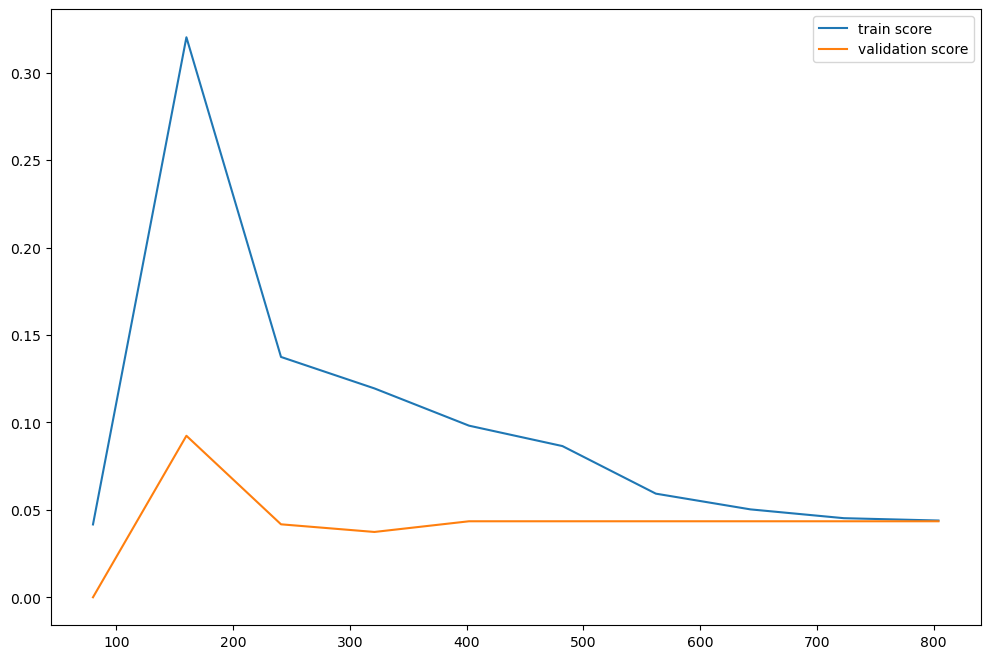

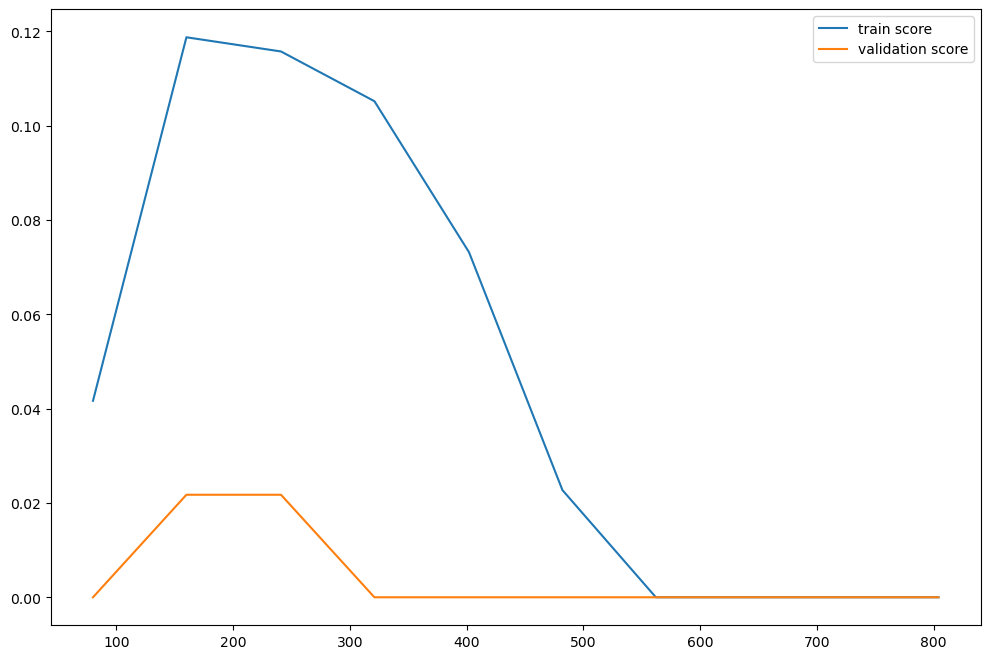

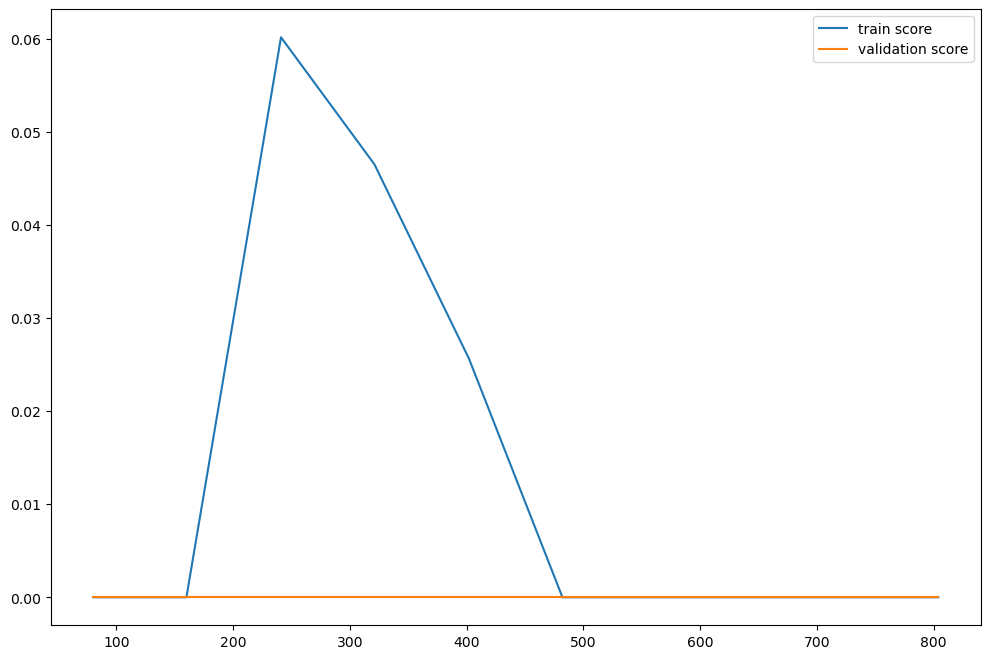

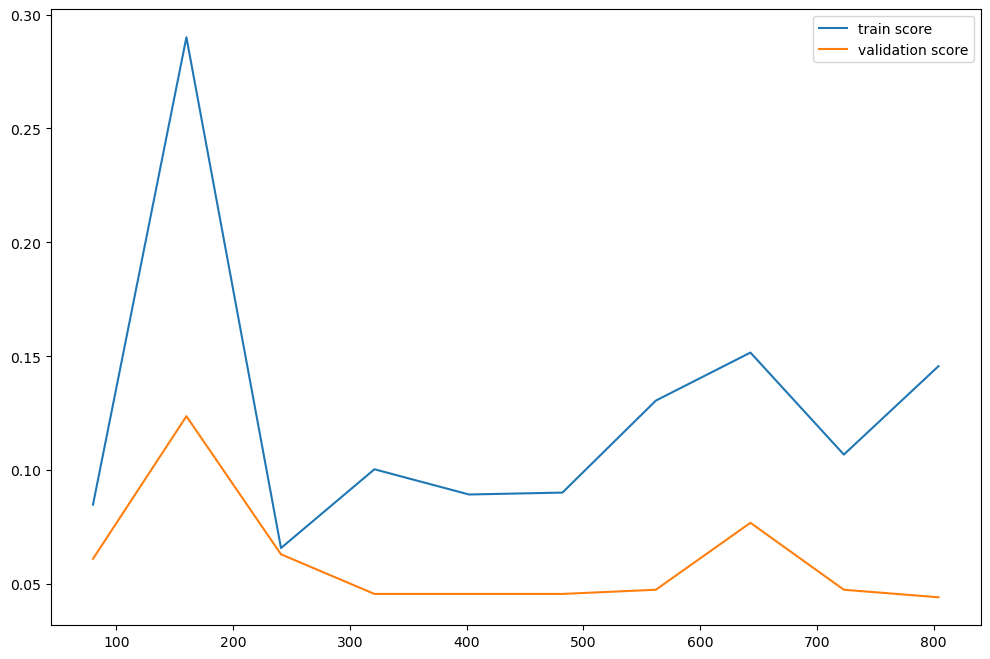

In [83]:
for name, model in dict_of_models.items():
    print(name)
    evaluation(model)

In [1]:
pd.DataFrame(model.feature_importances_, index=X_train.columns, columns=["Importance"]).sort_values(by="Importance", ascending=False)


NameError: name 'pd' is not defined

<Axes: >

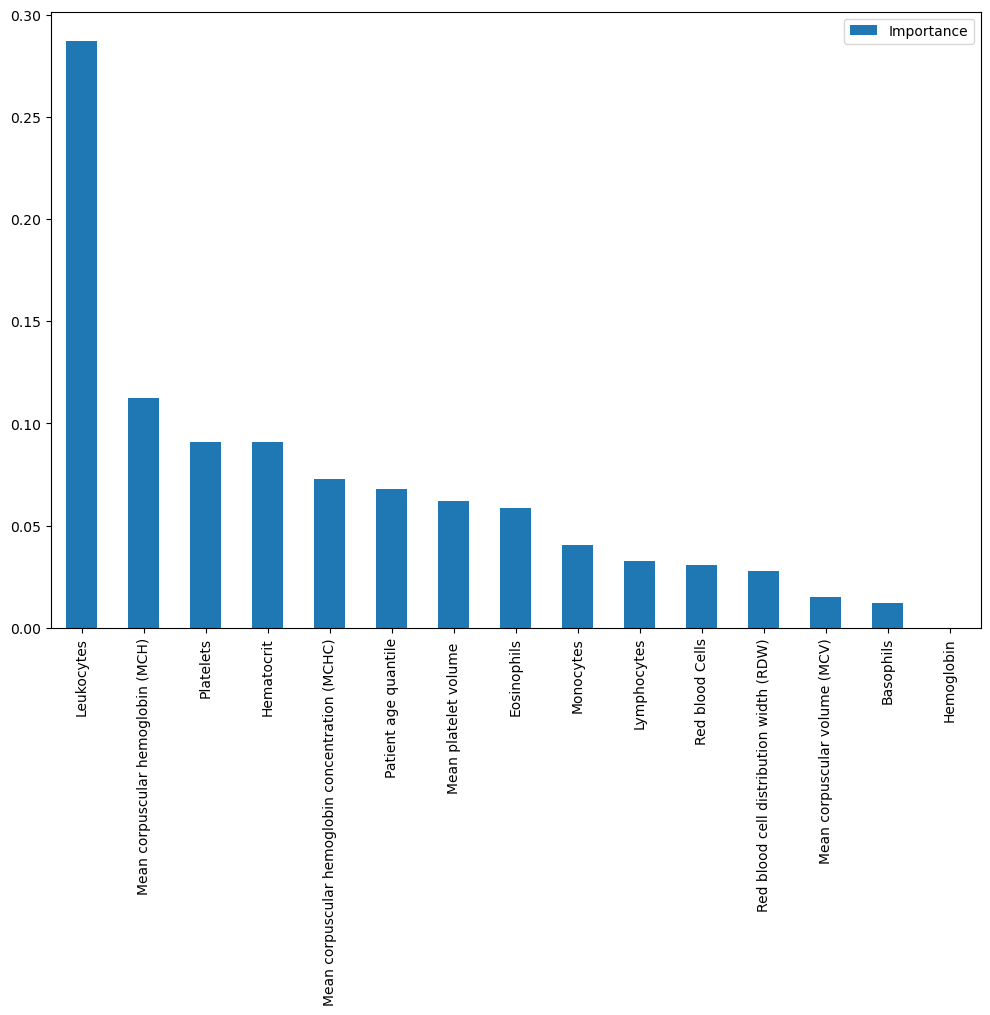

In [ ]:
pd.DataFrame(model.feature_importances_, index=X_train.columns, columns=["Importance"]).sort_values(by="Importance", ascending=False).plot.bar(figsize=(12, 8))